# Machine learning para series de tiempo
Este proyecto es un ejemplo básico de cómo implementar modelos de machine learning para series de tiempo.

## Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Preparación de los datos

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score

# Read DataFrame
df = pd.read_csv('/datasets/taxi.csv',sep = ',', header=0)

# Show DataFrame
df.head(3)

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28


Se hará un 'resample' de 1 hora.

In [2]:
# Convert the 'datetime' column to datetime objects (necessary for resampling)
df['datetime'] = pd.to_datetime(df['datetime'])

# Set column 'datetime' as index
df = df.set_index('datetime')

# Order index
df = df.sort_index(ascending=True)

# Resample by hour and sum data
df = df.resample('1h').sum()

# Show DataFrame
df.head(3)

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71


Se renombrará la columna 'num_orders' por target.

In [3]:
# Change column name
df.rename(columns={'num_orders': 'target'}, inplace=True)

## Estrategía de solución

Con la función 'make_features' se agregan las siguientes características:

1. Características de calendario (year, day, month, etc.), dado que por lo general, las tendencias y la estacionalidad se vinculan con una fecha específica.

2. Características de desfase (lag), ya que los valores anteriores en la serie temporal dirán si la función x(t) aumentará o disminuirá. Se usa el metodo 'shift()' y se crean las columnas 'lag_x'.

3. Característica de media móvil que establece la tendencia general de la serie temporal. Se usan los métodos 'shift()', 'rolling()' y 'mean()' para crear la columna 'rolling_mean'.

In [4]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['target'].shift(lag)
    data['rolling_mean'] = (data['target'].shift().rolling(rolling_mean_size).mean())
    return data

A continuación se muestra un ejemplo del uso de esta función. Más adelante se volverá a usar junto con el procedimiento de entrenamiento del modelo final.

In [5]:
# Copy DataFrame
df_example = df.copy()

# Create features
make_features(df_example, 2, 4)

# Show DataFrame
df_example.head(5)

,target,year,month,day,dayofweek,lag_1,lag_2,rolling_mean
datetime,,,,,,,,
2018-03-01 00:00:00,124,2018,3,1,3,NaN,NaN,NaN
2018-03-01 01:00:00,85,2018,3,1,3,124.0,NaN,NaN
2018-03-01 02:00:00,71,2018,3,1,3,85.0,124.0,NaN
2018-03-01 03:00:00,66,2018,3,1,3,71.0,85.0,NaN
2018-03-01 04:00:00,43,2018,3,1,3,66.0,71.0,86.5


Se muestran algunas columnas del DataFrame.

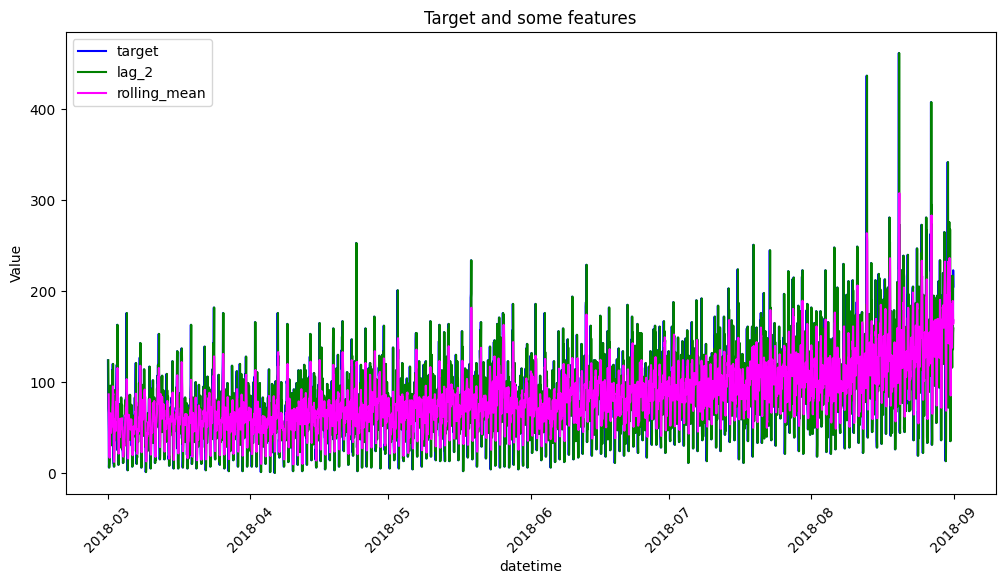

In [6]:
# Multiple Line plots
plt.figure(figsize = (12,6))
plt.plot(df_example['target'], color='blue', linestyle='-')
plt.plot(df_example['lag_2'], color='green', linestyle='-')
plt.plot(df_example['rolling_mean'], color='magenta', linestyle='-')
plt.title('Target and some features')
plt.legend(['target','lag_2','rolling_mean'])
plt.xlabel('datetime')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.show()

Al hacer un 'zoom in' se muestra la siguiente figura.

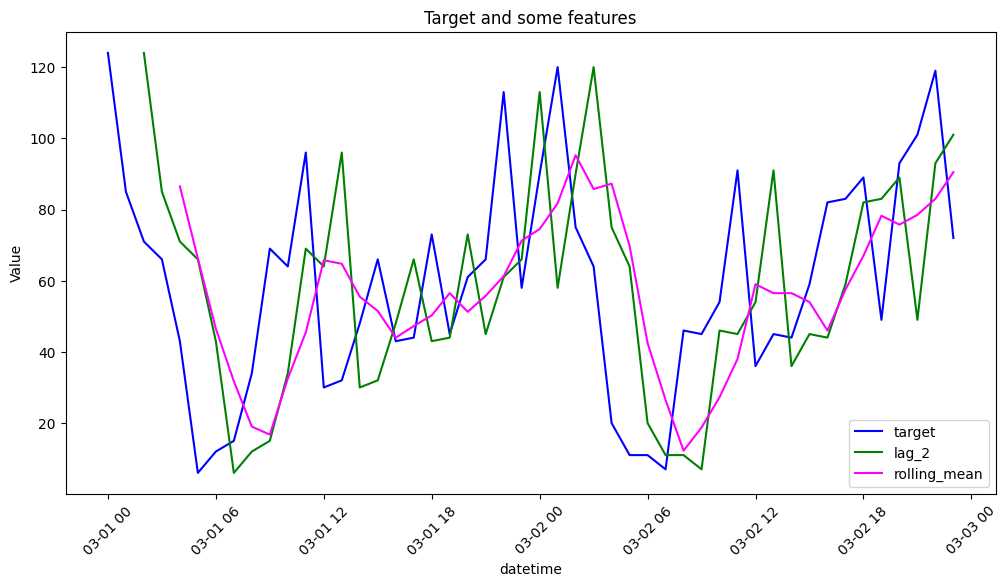

In [7]:
# Sample DataFrame
df_sample = df_example['2018-03-01':'2018-03-02']

# Multiple Line plots
plt.figure(figsize = (12,6))
plt.plot(df_sample['target'], color='blue', linestyle='-')
plt.plot(df_sample['lag_2'], color='green', linestyle='-')
plt.plot(df_sample['rolling_mean'], color='magenta', linestyle='-')
plt.title('Target and some features')
plt.legend(['target','lag_2','rolling_mean'])
plt.xlabel('datetime')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.show()

### Entrenammiento del modelo
A continuación se procede a entrenar diferentes modelos de regresión para determinar el que genera mejores resultados para este caso particular.

La métrica objetivo es RMSE.

In [8]:
# Create features to have more information for training
df = make_features(df.copy(), 25, 10)

# Split the dataset into training and testing sets (shuffle=False to maintain time order)
train, test = train_test_split(df, shuffle=False, test_size=0.1, random_state=0)
train = train.dropna()

# Obtain characteristic matrix (x) and objective variable (y)
x_train = train.drop('target',axis=1)
y_train = train['target']
x_test = test.drop('target',axis=1)
y_test = test['target']

def make_prediction(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print('MAE:{:.2f} RMSE:{:.2f}\n'
          .format(mean_absolute_error(y_test, y_pred), mean_squared_error(y_test, y_pred)**0.5))

In [9]:
# Define the regression models
models = [LinearRegression(), Lasso(random_state=0), Ridge(random_state=0),
          DecisionTreeRegressor(max_depth=80, criterion='mse', random_state=0),
          RandomForestRegressor(max_depth=20, n_estimators=50, criterion='mse', random_state=0),
          GradientBoostingRegressor(random_state=0, criterion='mse')]

In [10]:
# Iterate through the models and make predictions
for model in models:
    print(model)
    make_prediction(model, x_train, y_train, x_test, y_test)

LinearRegression()
MAE:33.68 RMSE:45.67

Lasso(random_state=0)
MAE:33.37 RMSE:45.22

Ridge(random_state=0)
MAE:33.68 RMSE:45.67

DecisionTreeRegressor(max_depth=80, random_state=0)
MAE:48.23 RMSE:66.15

RandomForestRegressor(max_depth=20, n_estimators=50, random_state=0)
MAE:32.38 RMSE:43.17

GradientBoostingRegressor(criterion='mse', random_state=0)
MAE:32.30 RMSE:43.19



## Conclusiones
De los resultados obtenidos, se puede observar que sólo el modelo 'DecisionTreeRegressor' no obtuvo un RMSE menor a 48. Se observa también que los modelos básicos de regresión lineal funcionan bien para el problema de regresión lineal para series temporales. Cabe mencionar que los argumentos de la función 'make_features(df.copy(), 25, 10)' son datos muy importantes, son hiperparámetros que podemos modificar para darle más información a los modelos. Finalmente, los mejores modelos para este caso particular son 'RandomForestRegressor' y 'GradientBoostingRegressor'.